# Notebook 04b — I-JEPA Full Fine-tuning RESUME
**Mục đích:** Resume Full FT từ checkpoint epoch 20 với LR cao hơn (1e-4/1e-5).
- LR cũ: HEAD=5e-5, ENC=5e-6 → quá thấp, AUC vẫn tăng đến epoch 20
- LR mới: HEAD=1e-4, ENC=1e-5 → tăng 2×, đúng với Partial FT
- Train thêm 15 epochs (epoch 21→35), resume từ best checkpoint epoch 20


In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================
import os, gc, json, math, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, confusion_matrix, accuracy_score
)

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","timm"])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(["pip","install","-q","pydicom"])
    import pydicom

SEED = 42
def set_seed(s=42):
    import random
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# CELL 2: TIME GUARD + OUTPUT DIRS
# ============================================================
SESSION_SAFE_HOURS   = 11.5
SESSION_SAFE_SECONDS = SESSION_SAFE_HOURS * 3600
NOTEBOOK_START_TIME  = time.time()

OUTPUT_DIR = Path("/kaggle/working/nb04b_resume")
CKPT_DIR   = OUTPUT_DIR / "checkpoints"
LOG_DIR    = OUTPUT_DIR / "logs"
FIG_DIR    = OUTPUT_DIR / "figures"
for d in [OUTPUT_DIR, CKPT_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Time guard: {SESSION_SAFE_HOURS}h")
print("Output:", OUTPUT_DIR)


Time guard: 11.5h
Output: /kaggle/working/nb04b_resume


In [3]:
# ============================================================
# CELL 3: TÌM INPUT FILES
# ============================================================
INPUT_ROOT   = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

# ── Encoder checkpoint từ Notebook 03 ────────────────────────
IJEPA_ENCODER_CKPT = find_file("ijepa_vit_small_nih_50k_best_encoder.pth")
print("Encoder ckpt  :", IJEPA_ENCODER_CKPT)

# ── Full FT checkpoint epoch 20 (để resume) ──────────────────
# File này từ output Notebook 04 version cũ
# Tên file: ijepa_full_finetune_best.pth
FULL_FT_RESUME_CKPT = find_file("ijepa_full_finetune_best.pth")
print("Full FT resume:", FULL_FT_RESUME_CKPT)

# ── RSNA CSVs ─────────────────────────────────────────────────
RSNA_TRAIN_CSV = find_file("rsna_train.csv")
RSNA_VAL_CSV   = find_file("rsna_val.csv")
RSNA_TEST_CSV  = find_file("rsna_test.csv")
print("Train CSV:", RSNA_TRAIN_CSV)
print("Val CSV  :", RSNA_VAL_CSV)
print("Test CSV :", RSNA_TEST_CSV)

assert IJEPA_ENCODER_CKPT   is not None, "Không tìm thấy encoder checkpoint NB03!"
assert FULL_FT_RESUME_CKPT  is not None, "Không tìm thấy full_ft_best.pth từ NB04!"
assert RSNA_TRAIN_CSV       is not None, "Không tìm thấy rsna_train.csv!"
print("\nAll inputs found ✓")


Encoder ckpt  : /kaggle/input/datasets/nguyentongphuc/nb04-full-ft-resume-ckpt/ijepa_vit_small_nih_50k_best_encoder.pth
Full FT resume: /kaggle/input/datasets/nguyentongphuc/nb04-full-ft-resume-ckpt/ijepa_full_finetune_best.pth
Train CSV: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
Val CSV  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
Test CSV : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv

All inputs found ✓


In [4]:
# ============================================================
# CELL 4: ĐỌC RSNA METADATA + TÍNH POS_WEIGHT
# ============================================================
train_df = pd.read_csv(RSNA_TRAIN_CSV)
val_df   = pd.read_csv(RSNA_VAL_CSV)
test_df  = pd.read_csv(RSNA_TEST_CSV)

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

n_neg = (train_df["label"] == 0).sum()
n_pos = (train_df["label"] == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32)
print(f"Train neg={n_neg} pos={n_pos} → POS_WEIGHT={POS_WEIGHT.item():.4f}")


Train: (18678, 4) | Val: (4003, 4) | Test: (4003, 4)
Train neg=14470 pos=4208 → POS_WEIGHT=3.4387


In [5]:
# ============================================================
# CELL 5: FIX ĐƯỜNG DẪN ẢNH RSNA
# ============================================================
def count_missing(df):
    return (~df["image_path"].apply(lambda x: Path(x).exists())).sum()

missing = count_missing(train_df)
print(f"Missing before fix: {missing}")

if missing > 0:
    all_imgs = list(INPUT_ROOT.rglob("*.dcm")) + list(INPUT_ROOT.rglob("*.png"))
    fname2path = {p.name: str(p) for p in all_imgs}

    def fix_path(p):
        return fname2path.get(Path(p).name, None)

    for df in [train_df, val_df, test_df]:
        df["image_path"] = df["image_path"].apply(fix_path)

    train_df.dropna(subset=["image_path"], inplace=True)
    val_df.dropna(subset=["image_path"], inplace=True)
    test_df.dropna(subset=["image_path"], inplace=True)

print(f"Missing after fix: {count_missing(train_df)}")


Missing before fix: 0
Missing after fix: 0


In [6]:
# ============================================================
# CELL 6: DATASET + TRANSFORMS
# ============================================================
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=7),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RSNADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["image_path"]
        if path.endswith(".dcm"):
            dcm = pydicom.dcmread(path)
            arr = dcm.pixel_array.astype(np.float32)
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
            img = Image.fromarray(arr.astype(np.uint8)).convert("RGB")
        else:
            img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row["label"], dtype=torch.float32)

BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = DataLoader(RSNADataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(RSNADataset(val_df,   eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(RSNADataset(test_df,  eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")


Train: 1168 batches | Val: 251 | Test: 251


In [7]:
# ============================================================
# CELL 7: MODEL ARCHITECTURE
# ============================================================
class IJEPAClassifier(nn.Module):
    """Giữ đúng kiến trúc gốc Notebook 04: LayerNorm → Dropout → Linear."""
    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        features = self.encoder(x)   # [B, embed_dim] — dùng forward() giống NB04 gốc
        logits   = self.classifier(features).squeeze(1)
        return logits


def create_ijepa_classifier():
    encoder = timm.create_model("vit_small_patch16_224", pretrained=False, num_classes=0)
    try:
        enc_ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        enc_ckpt = torch.load(IJEPA_ENCODER_CKPT, map_location="cpu")
    state_key = "encoder_state_dict" if "encoder_state_dict" in enc_ckpt else "student_encoder_state_dict"
    encoder.load_state_dict(enc_ckpt[state_key])
    embed_dim = encoder.num_features
    model = IJEPAClassifier(encoder, embed_dim=embed_dim, dropout=0.2)
    return model

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True
    print("All parameters unfrozen.")

def count_trainable(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {n:,}")

print("Model architecture defined ✓")


Model architecture defined ✓


In [8]:
# ============================================================
# CELL 8: TRAIN / EVALUATE HELPERS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, accum_steps):
    model.train()
    total_loss, total_steps = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, (images, labels) in enumerate(tqdm(loader, leave=False)):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
            loss   = criterion(logits, labels) / accum_steps
        scaler.scale(loss).backward()
        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss  += loss.item() * accum_steps
        total_steps += 1
    return total_loss / max(total_steps, 1)


def evaluate_model(model, loader, criterion, threshold=0.5):
    model.eval()
    all_probs, all_labels, total_loss, n = [], [], 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(images)
                loss   = criterion(logits, labels)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.cpu().numpy())
            total_loss += loss.item(); n += 1
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = (all_probs >= threshold).astype(int)
    auc  = roc_auc_score(all_labels, all_probs)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds, labels=[0,1]).ravel()
    metrics = {
        "auc": auc,
        "f1":  f1_score(all_labels, preds, zero_division=0),
        "recall_pneumonia": recall_score(all_labels, preds, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8),
        "precision":   precision_score(all_labels, preds, zero_division=0),
        "accuracy":    accuracy_score(all_labels, preds),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "threshold": threshold
    }
    pred_df = pd.DataFrame({"label": all_labels, "prob_pneumonia": all_probs,
                             "pred": preds})
    return total_loss / max(n, 1), metrics, pred_df


def make_lr_scheduler(optimizer, num_epochs, warmup_ratio=0.1):
    warmup_epochs = max(1, int(num_epochs * warmup_ratio))
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return float(ep + 1) / warmup_epochs
        progress = (ep - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def disk_used_gb():
    _, used, _ = shutil.disk_usage("/kaggle/working")
    return used / 1e9


def cleanup_checkpoints(model_name, keep_last=3):
    def ep_num(p):
        try: return int(p.stem.split("_epoch_")[-1])
        except: return -1
    for pattern in [f"{model_name}_last_epoch_*.pth"]:
        files = sorted(CKPT_DIR.glob(pattern), key=ep_num)
        for old in files[:-keep_last]:
            old.unlink(missing_ok=True)

print("Helpers defined ✓")


Helpers defined ✓


In [9]:
# ============================================================
# CELL 9: CONFIG RESUME FULL FT
# ============================================================
# ┌─────────────────────────────────────────────────────────┐
# │ Thay đổi so với lần chạy cũ (notebook 04):              │
# │   HEAD_LR  : 5e-5 → 1e-4  (tăng 2×)                   │
# │   ENCODER_LR: 5e-6 → 1e-5  (tăng 2×)                  │
# │   RESUME_EPOCH: 20 (bắt đầu đặt tên từ epoch 21)       │
# │   ADDITIONAL_EPOCHS: 15 (train thêm epoch 21→35)       │
# └─────────────────────────────────────────────────────────┘

HEAD_LR            = 1e-4       # tăng từ 5e-5
ENCODER_LR         = 1e-5       # tăng từ 5e-6
WEIGHT_DECAY       = 0.05
ACCUM_STEPS        = 2
PATIENCE           = 6
ADDITIONAL_EPOCHS  = 15         # train thêm epoch 21→35
RESUME_EPOCH       = 20         # epoch cuối của lần chạy trước
WARMUP_EPOCHS_ABS  = 2          # warmup tuyến tính 2 epochs đầu của session này
MODEL_NAME         = "ijepa_full_finetune_resume"

print(f"HEAD_LR={HEAD_LR} | ENCODER_LR={ENCODER_LR}")
print(f"Resume từ epoch {RESUME_EPOCH}, train thêm {ADDITIONAL_EPOCHS} epochs")
print(f"Tổng epochs sau resume: epoch {RESUME_EPOCH + ADDITIONAL_EPOCHS}")


HEAD_LR=0.0001 | ENCODER_LR=1e-05
Resume từ epoch 20, train thêm 15 epochs
Tổng epochs sau resume: epoch 35


In [10]:
# ============================================================
# CELL 10: BUILD MODEL + LOAD CHECKPOINT EPOCH 20
# ============================================================
full_model = create_ijepa_classifier()
unfreeze_all(full_model)
count_trainable(full_model)
full_model = full_model.to(DEVICE)

# Load state từ best checkpoint epoch 20
try:
    ckpt = torch.load(FULL_FT_RESUME_CKPT, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(FULL_FT_RESUME_CKPT, map_location=DEVICE)

full_model.load_state_dict(ckpt["model_state_dict"])
prev_auc = ckpt.get("best_auc", ckpt.get("val_auc", None))
print(f"Loaded checkpoint from: {FULL_FT_RESUME_CKPT.name}")
print(f"Previous best AUC: {prev_auc}")

# Verify load
full_model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = full_model(dummy)
    print(f"Forward pass OK — output shape: {out.shape}")


All parameters unfrozen.
Trainable params: 21,666,817
Loaded checkpoint from: ijepa_full_finetune_best.pth
Previous best AUC: 0.8193331884214448
Forward pass OK — output shape: torch.Size([2])


In [11]:
# ============================================================
# CELL 11: OPTIMIZER + LR SCHEDULER (RESUME)
# ============================================================
# LambdaLR với warmup ngắn 2 epochs đầu của session mới
# Sau warmup: cosine decay từ peak LR → ~0

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))

optimizer = torch.optim.AdamW([
    {"params": [p for p in full_model.encoder.parameters()    if p.requires_grad], "lr": ENCODER_LR},
    {"params": [p for p in full_model.classifier.parameters() if p.requires_grad], "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

def lr_lambda_resume(current_epoch):
    if current_epoch < WARMUP_EPOCHS_ABS:
        return float(current_epoch + 1) / WARMUP_EPOCHS_ABS
    progress = (current_epoch - WARMUP_EPOCHS_ABS) / max(1, ADDITIONAL_EPOCHS - WARMUP_EPOCHS_ABS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda_resume)
scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Preview LR schedule
print("LR schedule preview (epoch = vòng lặp mới, không phải epoch tuyệt đối):")
for ep in [0, 1, 2, 5, 10, 14]:
    factor = lr_lambda_resume(ep)
    print(f"  Local ep {ep:2d}: HEAD_LR={HEAD_LR*factor:.2e} | ENC_LR={ENCODER_LR*factor:.2e}")


LR schedule preview (epoch = vòng lặp mới, không phải epoch tuyệt đối):
  Local ep  0: HEAD_LR=5.00e-05 | ENC_LR=5.00e-06
  Local ep  1: HEAD_LR=1.00e-04 | ENC_LR=1.00e-05
  Local ep  2: HEAD_LR=1.00e-04 | ENC_LR=1.00e-05
  Local ep  5: HEAD_LR=8.74e-05 | ENC_LR=8.74e-06
  Local ep 10: HEAD_LR=3.23e-05 | ENC_LR=3.23e-06
  Local ep 14: HEAD_LR=1.45e-06 | ENC_LR=1.45e-07


/tmp/ipykernel_23/3540911078.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [12]:
# ============================================================
# CELL 12: VÒNG LẶP RESUME TRAINING
# ============================================================
best_auc         = prev_auc if prev_auc else 0.8193  # AUC tốt nhất từ run cũ
best_epoch_abs   = RESUME_EPOCH                       # epoch tuyệt đối
patience_counter = 0
history          = []
best_ckpt_path   = CKPT_DIR / f"{MODEL_NAME}_best.pth"

print(f"Starting resume from epoch {RESUME_EPOCH+1} → {RESUME_EPOCH+ADDITIONAL_EPOCHS}")
print(f"Best AUC to beat: {best_auc:.4f}")
print("=" * 58)

for local_ep in range(ADDITIONAL_EPOCHS):
    abs_epoch = RESUME_EPOCH + local_ep + 1  # epoch tuyệt đối: 21, 22, ...

    # Time guard
    if time.time() - NOTEBOOK_START_TIME > SESSION_SAFE_SECONDS:
        print(f"\n⏱  Time guard — dừng an toàn trước epoch {abs_epoch}.")
        break

    current_lr_head = optimizer.param_groups[1]["lr"]
    current_lr_enc  = optimizer.param_groups[0]["lr"]
    print(f"\nEpoch {abs_epoch} (local {local_ep+1}/{ADDITIONAL_EPOCHS}) | "
          f"HEAD_LR={current_lr_head:.2e} | ENC_LR={current_lr_enc:.2e}")

    # ── Train ────────────────────────────────────────────────
    train_loss = train_one_epoch(
        full_model, train_loader, optimizer, criterion, scaler, ACCUM_STEPS
    )
    scheduler.step()

    # ── Validate ─────────────────────────────────────────────
    val_loss, val_metrics, _ = evaluate_model(full_model, val_loader, criterion)

    print(f"  Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
    print(f"  AUC={val_metrics['auc']:.4f} | Recall={val_metrics['recall_pneumonia']:.4f} | "
          f"Spec={val_metrics['specificity']:.4f} | F1={val_metrics['f1']:.4f}")

    history.append({
        "abs_epoch": abs_epoch, "local_epoch": local_ep + 1,
        "train_loss": train_loss, "val_loss": val_loss,
        "lr_head": current_lr_head, "lr_enc": current_lr_enc,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    })

    # ── Last checkpoint + cleanup ────────────────────────────
    last_ckpt = CKPT_DIR / f"{MODEL_NAME}_last_epoch_{abs_epoch}.pth"
    torch.save({"model_state_dict": full_model.state_dict(),
                "abs_epoch": abs_epoch, "val_auc": val_metrics["auc"],
                "best_auc": best_auc}, last_ckpt)
    cleanup_checkpoints(MODEL_NAME, keep_last=3)
    print(f"  Disk: {disk_used_gb():.2f} GB")

    # ── Best checkpoint ───────────────────────────────────────
    current_auc = val_metrics["auc"]
    if current_auc > best_auc:
        best_auc       = current_auc
        best_epoch_abs = abs_epoch
        patience_counter = 0
        torch.save({"model_state_dict": full_model.state_dict(),
                    "abs_epoch": abs_epoch, "best_auc": best_auc,
                    "encoder_checkpoint": str(IJEPA_ENCODER_CKPT)},
                   best_ckpt_path)
        print(f"  ✓ New best AUC {best_auc:.4f} saved.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("  Early stopping.")
            break

    # ── Save history CSV ─────────────────────────────────────
    pd.DataFrame(history).to_csv(LOG_DIR / f"{MODEL_NAME}_history.csv", index=False)

print(f"\nBest AUC: {best_auc:.4f} at abs epoch {best_epoch_abs}")


Starting resume from epoch 21 → 35
Best AUC to beat: 0.8193

Epoch 21 (local 1/15) | HEAD_LR=5.00e-05 | ENC_LR=5.00e-06


  0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/4125159541.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_23/4125159541.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


  Train loss: 0.8173 | Val loss: 0.8148
  AUC=0.8202 | Recall=0.7882 | Spec=0.7169 | F1=0.5709
  Disk: 0.09 GB
  ✓ New best AUC 0.8202 saved.

Epoch 22 (local 2/15) | HEAD_LR=1.00e-04 | ENC_LR=1.00e-05


  0%|          | 0/1168 [00:00<?, ?it/s]

...

/tmp/ipykernel_23/4125159541.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aef07c30220>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aef07c30220>
Traceback (most recent call l

  Train loss: 0.7480 | Val loss: 0.8129
  AUC=0.8292 | Recall=0.7694 | Spec=0.7465 | F1=0.5827
  Disk: 0.35 GB
  ✓ New best AUC 0.8292 saved.

Epoch 35 (local 15/15) | HEAD_LR=1.45e-06 | ENC_LR=1.45e-07


  0%|          | 0/1168 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aef07c30220>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7aef07c30220>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

  Train loss: 0.7434 | Val loss: 0.8124
  AUC=0.8292 | Recall=0.7705 | Spec=0.7459 | F1=0.5828
  Disk: 0.35 GB
  No improvement. Patience: 1/6

Best AUC: 0.8292 at abs epoch 34


In [13]:
# ============================================================
# CELL 13: EVALUATE TRÊN TEST SET
# ============================================================
# Load best checkpoint của lần resume này
try:
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)

full_model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint: abs_epoch={ckpt['abs_epoch']} | AUC={ckpt['best_auc']:.4f}")

test_loss, test_metrics, test_pred_df = evaluate_model(
    full_model, test_loader, criterion, threshold=0.5
)

print("\n=== TEST SET RESULTS (threshold=0.5) ===")
for k, v in test_metrics.items():
    print(f"  {k:25s}: {v}")

# So sánh với lần chạy cũ
print("\n=== SO SÁNH VỚI RUN CŨ ===")
old_metrics = {"auc": 0.8137, "recall_pneumonia": 0.7461, "specificity": 0.7440, "f1": 0.5682}
for k, old_v in old_metrics.items():
    new_v = test_metrics.get(k, 0)
    delta = new_v - old_v
    print(f"  {k:25s}: {old_v:.4f} → {new_v:.4f}  ({delta:+.4f})")


Loaded best checkpoint: abs_epoch=34 | AUC=0.8292


/tmp/ipykernel_23/4125159541.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



=== TEST SET RESULTS (threshold=0.5) ===
  auc                      : 0.8296628081492916
  f1                       : 0.5751957148743304
  recall_pneumonia         : 0.7738359201773836
  specificity              : 0.7333118348896056
  precision                : 0.4577049180327869
  accuracy                 : 0.7424431676242818
  tn                       : 2274
  fp                       : 827
  fn                       : 204
  tp                       : 698
  threshold                : 0.5

=== SO SÁNH VỚI RUN CŨ ===
  auc                      : 0.8137 → 0.8297  (+0.0160)
  recall_pneumonia         : 0.7461 → 0.7738  (+0.0277)
  specificity              : 0.7440 → 0.7333  (-0.0107)
  f1                       : 0.5682 → 0.5752  (+0.0070)


Saved: full_ft_resume_test_metrics.csv


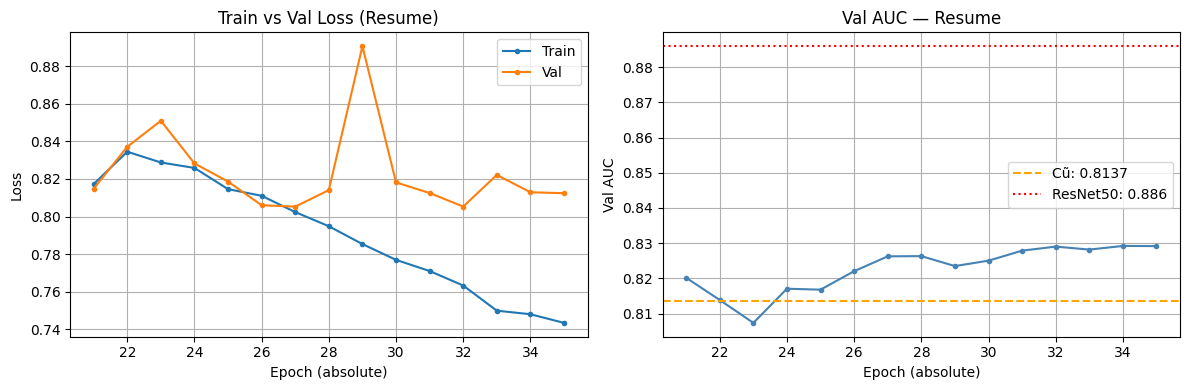

Saved figure.


In [14]:
# ============================================================
# CELL 14: LƯU KẾT QUẢ
# ============================================================
import matplotlib.pyplot as plt

# ── Save metrics CSV ─────────────────────────────────────────
results_df = pd.DataFrame([{
    "model": "I-JEPA Full FT Resume (ep21-35)",
    "test_loss": test_loss,
    **test_metrics
}])
results_df.to_csv(OUTPUT_DIR / "full_ft_resume_test_metrics.csv", index=False)
print("Saved: full_ft_resume_test_metrics.csv")

# ── Plot training curve ───────────────────────────────────────
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["abs_epoch"], history_df["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(history_df["abs_epoch"], history_df["val_loss"],   label="Val",   marker="o", markersize=3)
axes[0].set_xlabel("Epoch (absolute)"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Val Loss (Resume)"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_df["abs_epoch"], history_df["val_auc"], color="steelblue", marker="o", markersize=3)
axes[1].axhline(y=0.8137, color="orange", linestyle="--", label="Cũ: 0.8137")
axes[1].axhline(y=0.886,  color="red",    linestyle=":",  label="ResNet50: 0.886")
axes[1].set_xlabel("Epoch (absolute)"); axes[1].set_ylabel("Val AUC")
axes[1].set_title("Val AUC — Resume"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(FIG_DIR / "full_ft_resume_curves.png", dpi=150)
plt.show()
print("Saved figure.")


In [15]:
# ============================================================
# CELL 15: SUMMARY + FILES OUTPUT
# ============================================================
print("=== Files output ===")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUTPUT_DIR)}  ({p.stat().st_size/1e6:.1f} MB)")

print("\n=== Checkpoint để dùng cho Notebook 05 ===")
print(f"  {best_ckpt_path.name}")
print("  → Add output notebook này vào Notebook 05 như 1 Kaggle dataset")


=== Files output ===
  checkpoints/ijepa_full_finetune_resume_best.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_resume_last_epoch_33.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_resume_last_epoch_34.pth  (86.7 MB)
  checkpoints/ijepa_full_finetune_resume_last_epoch_35.pth  (86.7 MB)
  figures/full_ft_resume_curves.png  (0.1 MB)
  full_ft_resume_test_metrics.csv  (0.0 MB)
  logs/ijepa_full_finetune_resume_history.csv  (0.0 MB)

=== Checkpoint để dùng cho Notebook 05 ===
  ijepa_full_finetune_resume_best.pth
  → Add output notebook này vào Notebook 05 như 1 Kaggle dataset
